# Premise Health Case Study — Predicting (and Preventing) High-Cost Members

**Goal.** A small share of members drive most of the spend in any healthcare
population. This notebook (1) confirms that pattern, (2) builds a model to
**predict who will be high-cost** using only behavioural / clinical features —
no dollars — so the same model can flag *currently-healthy* members showing
early warning signs, and (3) wraps the model in an **agentic AI Care Navigator**
that produces a per-member briefing for outreach teams.

## Why this framing
Predicting cost from cost is trivial and not useful for prevention. The
interesting question — and the one with operational value — is *what
behavioural patterns separate high-cost members from everyone else?* Those
patterns are the **prevention levers** for healthy members.

## What's in this notebook
| Section | What |
|---|---|
| §1–2 | Setup, load, and clean the three sources |
| §3   | Join survey + claims, engineer features (utilization, diagnosis mix, sentiment) |
| §4   | EDA highlights — six visuals that tell the story |
| §5   | Predictive modeling (logistic + gradient boosting), diagnostics, interpretation |
| §6   | Agentic AI — Claude-powered Care Navigator with tool use |
| §7   | Takeaways with one slide per stakeholder |

**Author:** Yirang Cathy Li · **Role:** Data Scientist candidate, Premise Health


## 1. Setup

In [1]:
# Standard data-science stack — no exotic dependencies.
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42

DATA_DIR = "data"   # contains: claims_clean.csv, survey_clean.csv, member_claim_agg.csv


## 2. Load and clean

The raw `Case Study Data.xlsx` has three logical tables: a **member survey**
(demographics, risk scores, chronic flags, free-text feedback) and **claim
lines** (one row per service line). Cleaning was done in a separate prep notebook
(`01_Preparation.ipynb`); we load the cleaned outputs here and re-run the
critical type / missing-value checks for transparency.

Key cleaning decisions made in prep:
- Risk scores cast to numeric; ~7% missing on `Prospective Risk` and
  `Concurrent Risk` (highly correlated missingness — left as `NaN` and imputed
  at modeling time).
- Money columns stripped of `$` / `,`, cast to float. Placeholders revealed as
  `NaN` and treated as such (≈3% of paid amounts).
- Heavy right-skew on cost is **kept** — these are real, not outliers.
- One member has claims but no survey response (n=1) — dropped via inner join.


In [2]:
# Load the three cleaned tables produced by 01_Preparation.ipynb
survey = pd.read_csv(f"{DATA_DIR}/survey_clean.csv")
claims = pd.read_csv(f"{DATA_DIR}/claims_clean.csv")
member_agg = pd.read_csv(f"{DATA_DIR}/member_claim_agg.csv")  # per-member totals

print(f"Survey:     {survey.shape[0]:>6,} members  ×  {survey.shape[1]} cols")
print(f"Claims:     {claims.shape[0]:>6,} lines    ×  {claims.shape[1]} cols")
print(f"Member agg: {member_agg.shape[0]:>6,} members ×  {member_agg.shape[1]} cols")


Survey:      4,783 members  ×  22 cols
Claims:     144,247 lines    ×  18 cols
Member agg:  3,500 members ×  5 cols


In [3]:
# Quick sanity: missingness on the columns we'll lean on
need = ["Age", "Member Gender", "Prospective Risk", "Concurrent Risk",
        "# of Chronic Conditions", "Patient Survey Response"]
print("Survey missingness:")
print(survey[need].isna().mean().round(3).to_string())


Survey missingness:
Age                        0.000
Member Gender              0.000
Prospective Risk           0.076
Concurrent Risk            0.076
# of Chronic Conditions    0.000
Patient Survey Response    0.150


## 3. Join and feature engineering

Strategy:
- **Inner-join** survey ↔ member-aggregate on `Member ID`. The drop-outs
  (one-side-only members) were inspected in prep and are not informative for
  this study (1 claims-only member, ~1.3k survey-only members — these are
  healthy, no-claims members who don't help us learn cost drivers).
- Build features in four buckets, with one explicit rule: **never use anything
  derived from paid/allowed dollars** as a feature, because the target is
  defined from those same dollars.


In [4]:
# 3.1 Inner-join
member_df = survey.merge(member_agg, on="Member ID", how="inner")
print(f"Inner-joined cohort: {member_df.shape[0]:,} members")


Inner-joined cohort: 3,499 members


### 3.2 Define the prediction target

`high_cost_flag = 1` if a member's `total_paid` is in the **top 10%** of the
cohort. This is the standard "rising-risk" cutoff used by health plans for
care-management triage — small enough to be actionable, large enough to learn
from.


In [5]:
cost_threshold = member_df["total_paid"].quantile(0.90)
member_df["high_cost_flag"] = (member_df["total_paid"] >= cost_threshold).astype(int)
print(f"90th-pct cost threshold: ${cost_threshold:,.0f}")
print(f"Positive rate: {member_df['high_cost_flag'].mean():.1%}")


90th-pct cost threshold: $14,392
Positive rate: 10.0%


### 3.3 Utilization features

These are the **prevention-relevant** behavioural signals — observable from
claim activity *before* dollars accumulate.


In [6]:
# Place-of-service buckets — group 23 raw POS into three care intensities
PRIMARY_OUTPATIENT = ["Office", "Telehealth", "Urgent Care Facility",
                      "Walk-in Retail Health Clinic", "Rural Health Clinic"]
HOSPITAL_OUTPATIENT = ["Outpatient Hospital", "Emergency Room - Hospital"]
INPATIENT = ["Inpatient Hospital", "Inpatient Psychiatric Facility",
             "Skilled Nursing Facility"]

claims["is_primary_outpatient"]  = claims["Place of Service Description"].isin(PRIMARY_OUTPATIENT).astype(int)
claims["is_hospital_outpatient"] = claims["Place of Service Description"].isin(HOSPITAL_OUTPATIENT).astype(int)
claims["is_inpatient"]           = claims["Place of Service Description"].isin(INPATIENT).astype(int)

util = (claims.groupby("Member ID")
              .agg(n_total_claims=("Member ID", "size"),
                   n_primary_outpatient=("is_primary_outpatient", "sum"),
                   n_hospital_outpatient=("is_hospital_outpatient", "sum"),
                   n_inpatient=("is_inpatient", "sum"))
              .reset_index())
util["pct_primary_outpatient"] = (util["n_primary_outpatient"] /
                                    util["n_total_claims"]).fillna(0)

member_df = member_df.merge(util, on="Member ID", how="left")

# Care fragmentation: how many distinct provider-specialties did the member touch?
# (This dataset has no Provider ID; "Speciality" is the most granular proxy.)
diversity = (claims.groupby("Member ID")
                    .agg(n_distinct_specialities=("Speciality", "nunique"))
                    .reset_index())
member_df = member_df.merge(diversity, on="Member ID", how="left")
member_df["n_distinct_specialities"] = member_df["n_distinct_specialities"].fillna(0)

# Composite risk flag: chronic patient with low primary-care use (an early warning)
member_df["any_chronic"] = (member_df["# of Chronic Conditions"] > 0).astype(int)
member_df["chronic_low_primary"] = (
    (member_df["any_chronic"] == 1) &
    (member_df["pct_primary_outpatient"] < member_df["pct_primary_outpatient"].median())
).astype(int)

member_df.filter(regex="^n_|pct_|chronic").head()


,n_claims,n_lines,n_total_claims,n_primary_outpatient,n_hospital_outpatient,n_inpatient,pct_primary_outpatient,n_distinct_specialities,any_chronic,chronic_low_primary
0,65,207,207,26,98,80,0.125604,18,1,1
1,13,16,16,13,3,0,0.812500,5,1,0
2,19,28,28,16,0,0,0.571429,3,1,1
3,4,9,9,6,3,0,0.666667,4,1,0
4,1,2,2,2,0,0,1.000000,1,0,0


### 3.4 Diagnosis and procedure mix

One-hot counts for the top diagnosis super-groups (top 10) and procedure
groups (top 8). This captures *what kind* of care the member is using.


In [7]:
def topk_one_hot(df, group_col, k, prefix):
    """Pivot top-k values of `group_col` into per-member counts."""
    top = df[group_col].value_counts().head(k).index
    sub = df[df[group_col].isin(top)]
    counts = (sub.groupby(["Member ID", group_col]).size()
                  .unstack(fill_value=0))
    counts.columns = [f"{prefix}_{c.lower().replace('/','_').replace(' ','_').replace('-','_')}"
                       for c in counts.columns]
    return counts.reset_index()

dx = topk_one_hot(claims, "Diagnosis Super-Grouper 1 Desc", k=10, prefix="dx")
proc = topk_one_hot(claims, "Procedure Grouper Desc", k=8, prefix="proc")

member_df = member_df.merge(dx, on="Member ID", how="left")
member_df = member_df.merge(proc, on="Member ID", how="left")
fe_cols = [c for c in member_df.columns if c.startswith(("dx_", "proc_"))]
member_df[fe_cols] = member_df[fe_cols].fillna(0)
print(f"Added {len(fe_cols)} diagnosis + procedure-mix features.")


Added 18 diagnosis + procedure-mix features.


### 3.5 Survey-text NLP signal

The free-text response is short and inconsistent, so we extract two robust
features:
- **`survey_sentiment`** — VADER compound score (rule-based, well-suited to short
  reviews; falls back to a tiny keyword scorer if NLTK isn't installed).
- **`survey_complaint_flag`** — 1 if response contains negative-care keywords.

These complement the structured features and let us test whether **patient
experience** correlates with cost.


In [8]:
def get_sentiment_scorer():
    """Return a callable polarity_scores(text)->{'compound':float}."""
    try:
        import nltk
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        try:
            return SentimentIntensityAnalyzer()
        except LookupError:
            nltk.download("vader_lexicon", quiet=True)
            return SentimentIntensityAnalyzer()
    except ImportError:
        POS = {"great", "good", "love", "excellent", "helpful", "caring",
               "compassionate", "recommend", "kind", "attentive"}
        NEG = {"rude", "ignore", "rushed", "wait", "frustrating", "unhelpful",
               "bad", "terrible", "dismissive", "wrong"}
        class _F:
            def polarity_scores(self, t):
                tl = (t or "").lower()
                p = sum(w in tl for w in POS); n = sum(w in tl for w in NEG)
                return {"compound": (p - n) / max(p + n, 1)}
        return _F()

sia = get_sentiment_scorer()
COMPLAINT_KW = ["listen", "wait", "rude", "ignore", "rushed", "dismiss",
                "frustrat", "wrong", "unhelpful", "don't hear"]

def sentiment(t):
    return sia.polarity_scores(t)["compound"] if isinstance(t, str) and t.strip() else 0.0
def is_complaint(t):
    return int(any(k in t.lower() for k in COMPLAINT_KW)) if isinstance(t, str) else 0

member_df["survey_sentiment"] = member_df["Patient Survey Response"].apply(sentiment)
member_df["survey_complaint_flag"] = member_df["Patient Survey Response"].apply(is_complaint)
member_df["survey_response_present"] = member_df["Patient Survey Response"].notna().astype(int)

# First look at the signal — high-cost members report worse experiences
member_df.groupby("high_cost_flag")[
    ["survey_sentiment", "survey_complaint_flag", "survey_response_present"]
].mean().round(3)


,survey_sentiment,survey_complaint_flag,survey_response_present
high_cost_flag,,,
0,0.268,0.186,0.843
1,0.150,0.189,0.854


### 3.6 Build the modeling matrix (with explicit leakage rules)

Rule of thumb: **anything derived from paid or allowed dollars in the same
period as the target is leakage.** We also drop `Concurrent Risk` (computed
from the same period) but keep `Prospective Risk` (forward-looking, intended
for prediction).


In [9]:
LEAKAGE_COLS = [
    "total_paid", "total_allowed",       # the target itself
    "Concurrent Risk",                    # same-period risk score
    "Patient Survey Response",            # raw text — already encoded
]

model_df = pd.get_dummies(member_df.copy(),
                           columns=["Member Gender"], drop_first=True)

drop_cols = [c for c in LEAKAGE_COLS if c in model_df.columns]
X = (model_df.drop(columns=["Member ID", "high_cost_flag"] + drop_cols)
              .select_dtypes(include=["number", "bool"])
              .astype(float))
y = model_df["high_cost_flag"].astype(int)

print(f"Modeling matrix: {X.shape[0]:,} rows × {X.shape[1]} features  "
      f"(positive rate {y.mean():.1%})")


Modeling matrix: 3,499 rows × 50 features  (positive rate 10.0%)


## 4. EDA highlights

Six visuals that drive the narrative.


### 4.1 Cost is highly concentrated

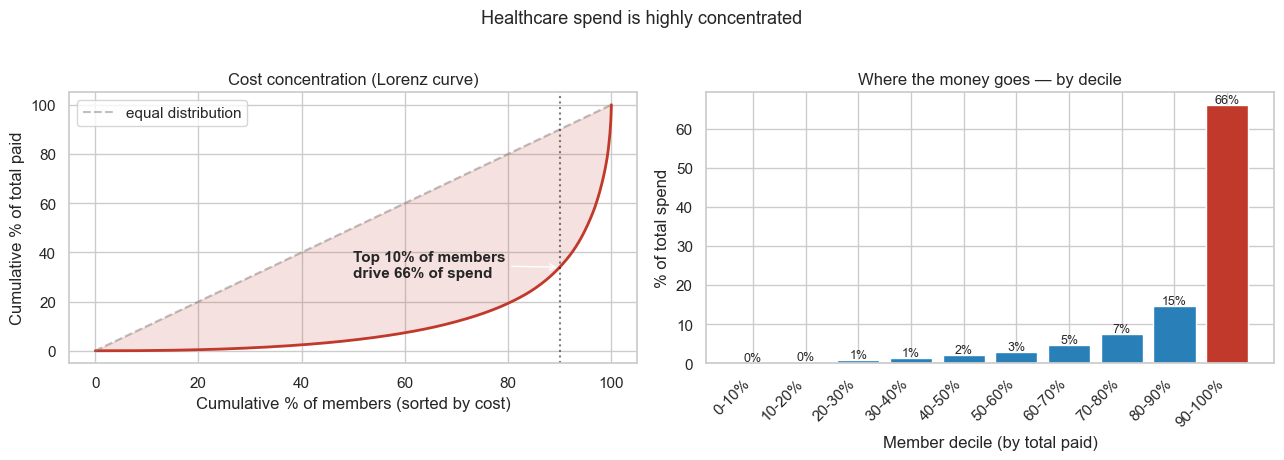


Top 10% of members → 66.0% of paid amount.
Top  1% of members → 23.7% of paid amount.


In [10]:
sorted_paid = np.sort(member_df["total_paid"].fillna(0).values)
n = len(sorted_paid)
cum_share = np.cumsum(sorted_paid) / sorted_paid.sum()
member_share = np.arange(1, n + 1) / n

deciles = pd.qcut(member_df["total_paid"].rank(method="first"), 10, labels=False)
decile_share = (member_df.groupby(deciles)["total_paid"].sum()
                / member_df["total_paid"].sum() * 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Lorenz
axes[0].plot(member_share * 100, cum_share * 100, color="#c0392b", lw=2)
axes[0].plot([0, 100], [0, 100], "--", color="gray", alpha=0.5, label="equal distribution")
axes[0].fill_between(member_share * 100, cum_share * 100, member_share * 100,
                      color="#c0392b", alpha=0.15)
top_10_share = (1 - cum_share[int(n * 0.9) - 1]) * 100
axes[0].axvline(90, ls=":", color="black", alpha=0.5)
axes[0].annotate(f"Top 10% of members\ndrive {top_10_share:.0f}% of spend",
                  xy=(90, 100 - top_10_share), xytext=(50, 30),
                  arrowprops=dict(arrowstyle="->"), fontsize=11, fontweight="bold")
axes[0].set(xlabel="Cumulative % of members (sorted by cost)",
             ylabel="Cumulative % of total paid",
             title="Cost concentration (Lorenz curve)")
axes[0].legend(loc="upper left")

# Pareto
axes[1].bar(range(10), decile_share.values, color="#2980b9", edgecolor="white")
axes[1].bar(9, decile_share.values[-1], color="#c0392b", edgecolor="white")
axes[1].set_xticks(range(10))
axes[1].set_xticklabels([f"{i*10}-{(i+1)*10}%" for i in range(10)],
                          rotation=45, ha="right")
axes[1].set(xlabel="Member decile (by total paid)",
             ylabel="% of total spend",
             title="Where the money goes — by decile")
for i, v in enumerate(decile_share.values):
    axes[1].text(i, v + 0.5, f"{v:.0f}%", ha="center", fontsize=9)

plt.suptitle("Healthcare spend is highly concentrated", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
print(f"\nTop 10% of members → {top_10_share:.1f}% of paid amount.")
print(f"Top  1% of members → {(1 - cum_share[int(n*0.99) - 1])*100:.1f}% of paid amount.")


### 4.2 Cost rises steeply with chronic-condition burden

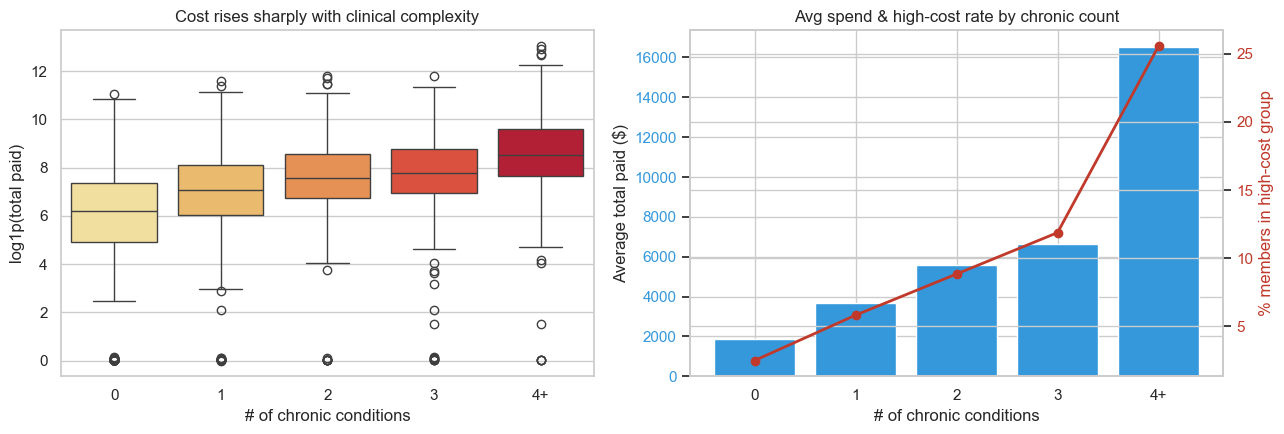

chronic_bucket     avg_paid  high_cost_rate    n
             0  1849.890867        0.024908 1084
             1  3688.820406        0.058187  739
             2  5585.397293        0.088398  543
             3  6638.845724        0.118765  421
            4+ 16532.809565        0.255618  712


In [11]:
plot_df = member_df.copy()
plot_df["log_paid"] = np.log1p(plot_df["total_paid"].fillna(0))
plot_df["chronic_bucket"] = pd.cut(plot_df["# of Chronic Conditions"],
                                     bins=[-1, 0, 1, 2, 3, 99],
                                     labels=["0", "1", "2", "3", "4+"])

agg = (plot_df.groupby("chronic_bucket", observed=True)
              .agg(avg_paid=("total_paid", "mean"),
                   high_cost_rate=("high_cost_flag", "mean"),
                   n=("Member ID", "nunique"))
              .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=plot_df, x="chronic_bucket", y="log_paid", ax=axes[0],
             palette="YlOrRd", hue="chronic_bucket", legend=False)
axes[0].set(xlabel="# of chronic conditions", ylabel="log1p(total paid)",
             title="Cost rises sharply with clinical complexity")

ax = axes[1]
ax.bar(agg["chronic_bucket"].astype(str), agg["avg_paid"],
        color="#3498db", edgecolor="white")
ax.set(xlabel="# of chronic conditions",
        ylabel="Average total paid ($)",
        title="Avg spend & high-cost rate by chronic count")
ax.tick_params(axis="y", labelcolor="#3498db")
ax2 = ax.twinx()
ax2.plot(agg["chronic_bucket"].astype(str), agg["high_cost_rate"] * 100,
         color="#c0392b", marker="o", lw=2)
ax2.set_ylabel("% members in high-cost group", color="#c0392b")
ax2.tick_params(axis="y", labelcolor="#c0392b")
plt.tight_layout(); plt.show()
print(agg.to_string(index=False))


### 4.3 High-cost members shift toward hospital-based care

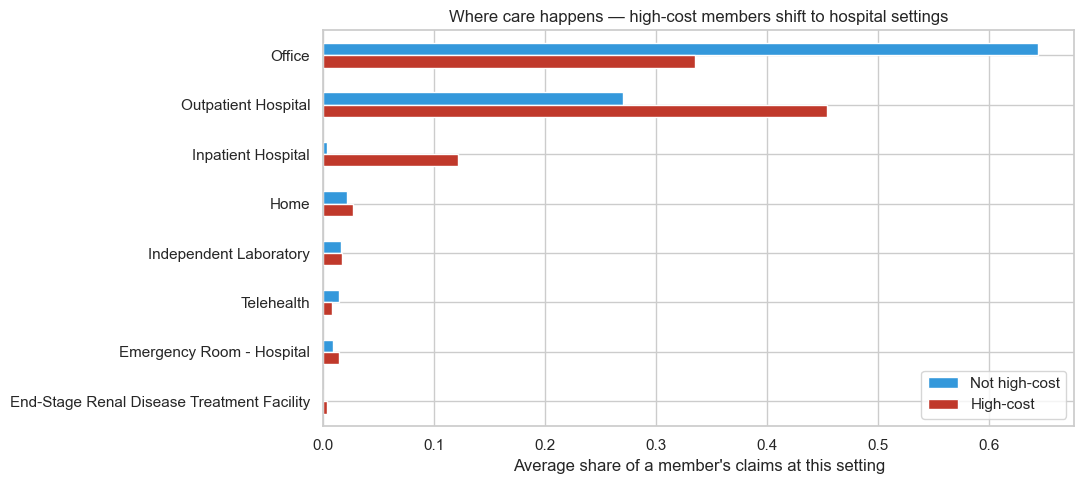

In [12]:
pos_per_member = (claims.groupby(["Member ID", "Place of Service Description"])
                          .size().unstack(fill_value=0))
pos_share = pos_per_member.div(pos_per_member.sum(axis=1), axis=0)
flag = member_df.set_index("Member ID")["high_cost_flag"]
pos_share = pos_share.join(flag, how="inner")

top_pos = pos_per_member.sum().sort_values(ascending=False).head(8).index
mean_share = (pos_share.groupby("high_cost_flag")[top_pos].mean()
              .rename(index={0: "Not high-cost", 1: "High-cost"}))

ax = mean_share.T.plot(kind="barh", figsize=(11, 5),
                        color=["#3498db", "#c0392b"], edgecolor="white")
ax.set(xlabel="Average share of a member's claims at this setting",
        title="Where care happens — high-cost members shift to hospital settings")
ax.legend(title="", loc="lower right")
ax.invert_yaxis()
plt.tight_layout(); plt.show()


### 4.4 Where the dollars go (top diagnosis groups)

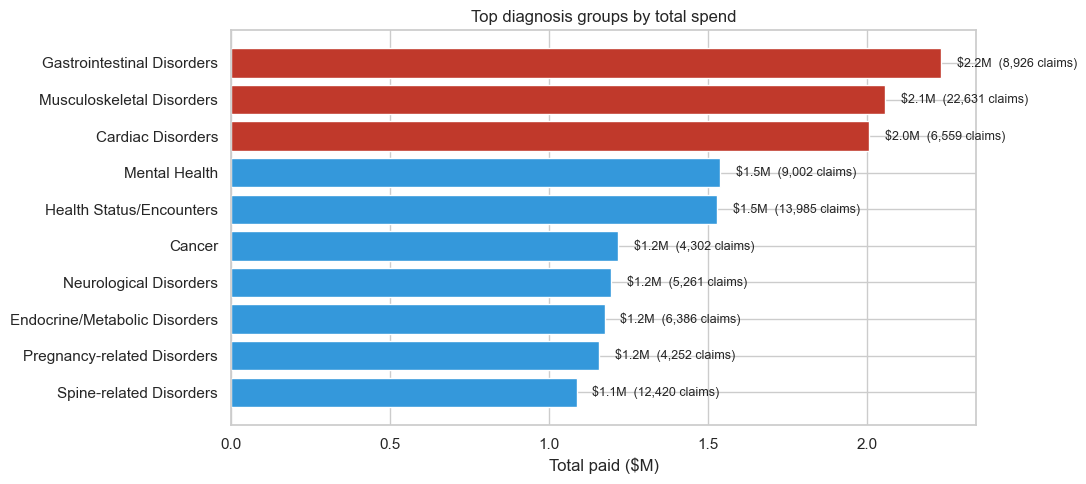

In [13]:
dx_cost = (claims.groupby("Diagnosis Super-Grouper 1 Desc")
                  .agg(total_paid=("Paid Amount", "sum"),
                       n_claims=("Claim Number", "count"))
                  .sort_values("total_paid", ascending=False).head(10))

fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#c0392b" if i < 3 else "#3498db" for i in range(len(dx_cost))]
bars = ax.barh(dx_cost.index[::-1], dx_cost["total_paid"][::-1] / 1e6,
                color=colors[::-1], edgecolor="white")
ax.set(xlabel="Total paid ($M)",
        title="Top diagnosis groups by total spend")
for b, v, n in zip(bars, dx_cost["total_paid"][::-1] / 1e6,
                    dx_cost["n_claims"][::-1]):
    ax.text(v + 0.05, b.get_y() + b.get_height() / 2,
            f"${v:.1f}M  ({n:,} claims)", va="center", fontsize=9)
plt.tight_layout(); plt.show()


### 4.5 Patient experience signal

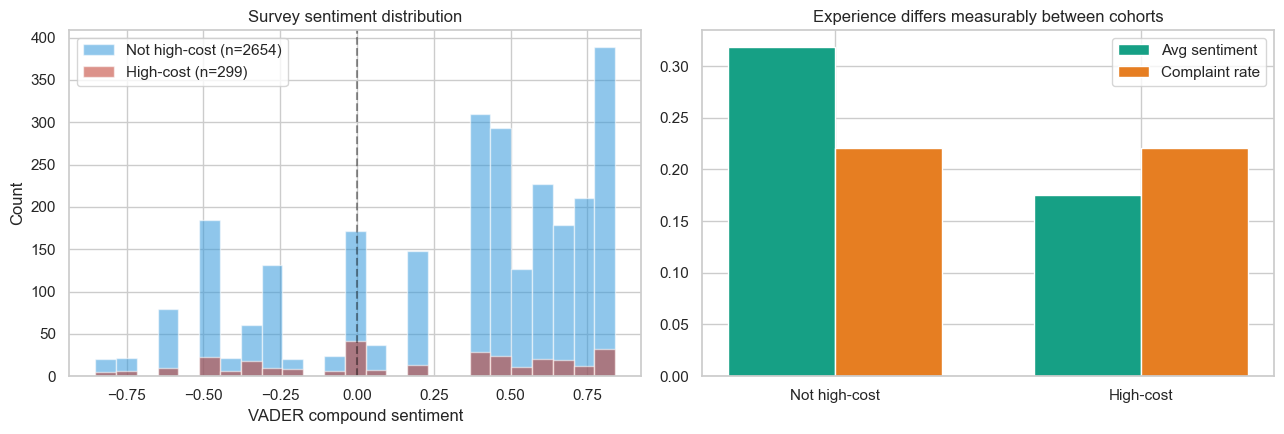

high_cost_flag  avg_sentiment  complaint_rate
 Not high-cost       0.318555        0.220422
     High-cost       0.175653        0.220736


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Sentiment overlay
for flag, color, label in [(0, "#3498db", "Not high-cost"),
                             (1, "#c0392b", "High-cost")]:
    s = member_df.loc[(member_df["high_cost_flag"] == flag) &
                       (member_df["survey_response_present"] == 1),
                       "survey_sentiment"]
    axes[0].hist(s, bins=25, alpha=0.55, label=f"{label} (n={len(s)})",
                  color=color, edgecolor="white")
axes[0].axvline(0, color="black", ls="--", alpha=0.4)
axes[0].set(xlabel="VADER compound sentiment", ylabel="Count",
             title="Survey sentiment distribution")
axes[0].legend()

summary = (member_df[member_df["survey_response_present"] == 1]
           .groupby("high_cost_flag")
           .agg(avg_sentiment=("survey_sentiment", "mean"),
                complaint_rate=("survey_complaint_flag", "mean"))
           .reset_index())
summary["high_cost_flag"] = summary["high_cost_flag"].map(
    {0: "Not high-cost", 1: "High-cost"})

x = np.arange(len(summary)); width = 0.35
axes[1].bar(x - width/2, summary["avg_sentiment"], width,
             color="#16a085", label="Avg sentiment", edgecolor="white")
axes[1].bar(x + width/2, summary["complaint_rate"], width,
             color="#e67e22", label="Complaint rate", edgecolor="white")
axes[1].set_xticks(x); axes[1].set_xticklabels(summary["high_cost_flag"])
axes[1].set_title("Experience differs measurably between cohorts")
axes[1].legend()
plt.tight_layout(); plt.show()
print(summary.to_string(index=False))


### 4.6 Risk × cost — the structure of who is expensive

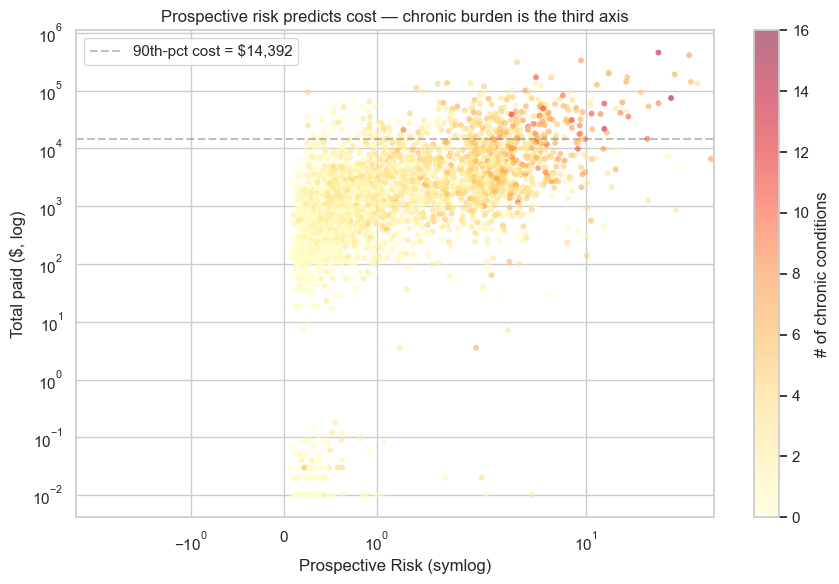

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_df = member_df.dropna(subset=["Prospective Risk", "total_paid"]).copy()
plot_df = plot_df[plot_df["total_paid"] > 0]
sc = ax.scatter(plot_df["Prospective Risk"], plot_df["total_paid"],
                 c=plot_df["# of Chronic Conditions"], cmap="YlOrRd",
                 s=18, alpha=0.55, edgecolor="none")
ax.set_yscale("log"); ax.set_xscale("symlog")
ax.set(xlabel="Prospective Risk (symlog)",
        ylabel="Total paid ($, log)",
        title="Prospective risk predicts cost — chronic burden is the third axis")
plt.colorbar(sc, ax=ax, label="# of chronic conditions")
ax.axhline(member_df["total_paid"].quantile(0.9), ls="--", color="gray",
            alpha=0.5, label=f"90th-pct cost = ${member_df['total_paid'].quantile(0.9):,.0f}")
ax.legend()
plt.tight_layout(); plt.show()


## 5. Predictive modeling

**Target.** `high_cost_flag` — top-10% of members by `total_paid`.

**Two complementary models.**
- **Logistic regression** — interpretable baseline; coefficients give clean directional signal.
- **Gradient boosting** (`HistGradientBoostingClassifier`) — captures interactions; SHAP explains per-prediction contributions.

**Metrics.** Average Precision (PR-AUC) is the primary metric — the cohort is
imbalanced (~10% positive) and we care about ranking quality, not raw accuracy.
ROC-AUC is reported alongside.


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, roc_curve, precision_recall_curve,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

logit = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("clf",     LogisticRegression(max_iter=2000, class_weight="balanced",
                                    solver="liblinear", random_state=RANDOM_STATE)),
])
gbm = HistGradientBoostingClassifier(
    max_iter=400, max_depth=6, learning_rate=0.05,
    class_weight="balanced", random_state=RANDOM_STATE,
)

logit.fit(X_train, y_train); gbm.fit(X_train, y_train)
logit_proba = logit.predict_proba(X_test)[:, 1]
gbm_proba   = gbm.predict_proba(X_test)[:, 1]

print(f"{'Model':<10s} {'ROC-AUC':>9s} {'PR-AUC':>9s}")
for name, p in [("Logistic", logit_proba), ("GBM", gbm_proba)]:
    print(f"{name:<10s} {roc_auc_score(y_test, p):>9.3f} {average_precision_score(y_test, p):>9.3f}")


Model        ROC-AUC    PR-AUC
Logistic       0.995     0.920
GBM            0.995     0.947


### 5.1 ROC and PR curves

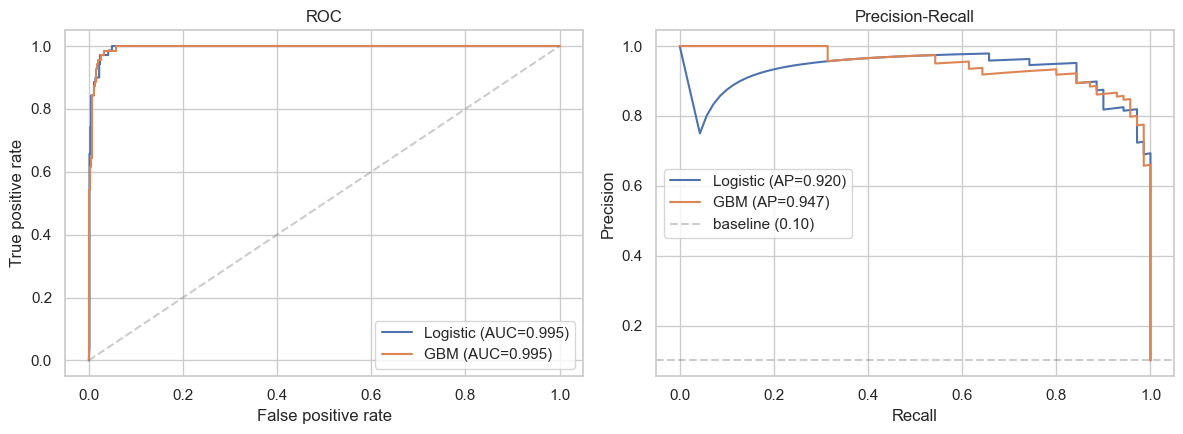

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, p in [("Logistic", logit_proba), ("GBM", gbm_proba)]:
    fpr, tpr, _ = roc_curve(y_test, p)
    pr, rc, _ = precision_recall_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, p):.3f})")
    axes[1].plot(rc, pr, label=f"{name} (AP={average_precision_score(y_test, p):.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="gray", alpha=0.4)
axes[0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC")
axes[0].legend()
axes[1].axhline(y_test.mean(), ls="--", color="gray", alpha=0.4,
                 label=f"baseline ({y_test.mean():.2f})")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall")
axes[1].legend()
plt.tight_layout(); plt.show()


### 5.2 Diagnostics for the operations team
Three checks that decide whether the model can actually be deployed.


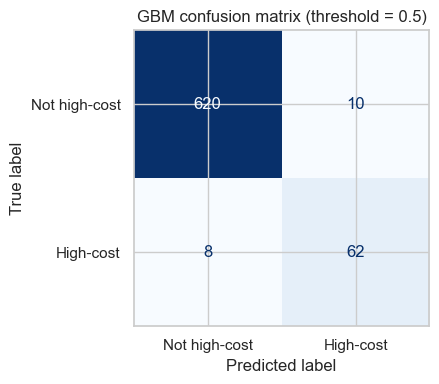

Recall on high-cost: 88.6%  |  Precision: 86.1%
Missed high-cost (FN): 8 of 70


In [18]:
# Confusion matrix at the chosen threshold
threshold = 0.5
y_pred = (gbm_proba >= threshold).astype(int)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Not high-cost", "High-cost"]).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title(f"GBM confusion matrix (threshold = {threshold})")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Recall on high-cost: {tp/(tp+fn):.1%}  |  Precision: {tp/(tp+fp):.1%}")
print(f"Missed high-cost (FN): {fn} of {tp+fn}")


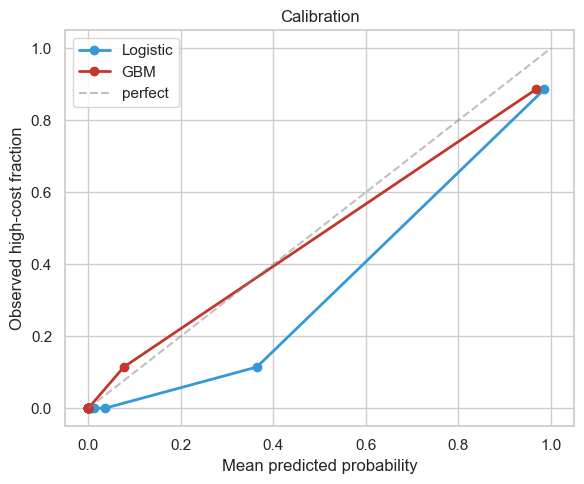

In [19]:
# Calibration — are predicted probabilities trustworthy as risk scores?
fig, ax = plt.subplots(figsize=(6, 5))
for name, p, color in [("Logistic", logit_proba, "#3498db"),
                         ("GBM",      gbm_proba,   "#c0392b")]:
    frac, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac, marker="o", lw=2, color=color, label=name)
ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.5, label="perfect")
ax.set(xlabel="Mean predicted probability",
        ylabel="Observed high-cost fraction",
        title="Calibration")
ax.legend()
plt.tight_layout(); plt.show()


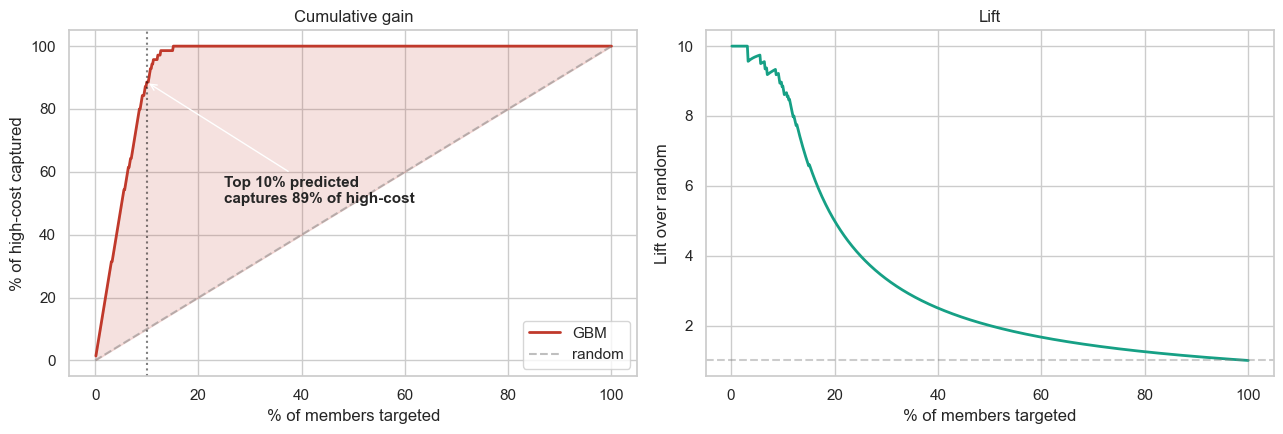

At top 10% targeted: capture 89% of high-cost  (8.9× random).


In [20]:
# Cumulative-gain & lift — the actionability story
order = np.argsort(-gbm_proba)
y_sorted = y_test.values[order]
cum_pos = np.cumsum(y_sorted)
total_pos = cum_pos[-1]
n_t = len(y_sorted)
pct_targeted = np.arange(1, n_t + 1) / n_t * 100
pct_captured = cum_pos / total_pos * 100
lift = pct_captured / pct_targeted

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(pct_targeted, pct_captured, color="#c0392b", lw=2, label="GBM")
axes[0].plot([0, 100], [0, 100], "--", color="gray", alpha=0.5, label="random")
axes[0].fill_between(pct_targeted, pct_targeted, pct_captured,
                      alpha=0.15, color="#c0392b")
idx10 = int(n_t * 0.10) - 1
captured_at_10 = pct_captured[idx10]
axes[0].axvline(10, ls=":", color="black", alpha=0.5)
axes[0].annotate(f"Top 10% predicted\ncaptures {captured_at_10:.0f}% of high-cost",
                  xy=(10, captured_at_10), xytext=(25, 50),
                  arrowprops=dict(arrowstyle="->"), fontsize=11, fontweight="bold")
axes[0].set(xlabel="% of members targeted", ylabel="% of high-cost captured",
             title="Cumulative gain")
axes[0].legend(loc="lower right")

axes[1].plot(pct_targeted, lift, color="#16a085", lw=2)
axes[1].axhline(1, ls="--", color="gray", alpha=0.4)
axes[1].set(xlabel="% of members targeted", ylabel="Lift over random",
             title="Lift")
plt.tight_layout(); plt.show()
print(f"At top 10% targeted: capture {captured_at_10:.0f}% of high-cost  "
      f"({lift[idx10]:.1f}× random).")


### 5.3 What signals high-cost? — interpretation

Permutation importance tells us which features the model relies on most.
SHAP values then break down individual predictions — those are what the agent
in §6 uses to give *personalized* explanations.


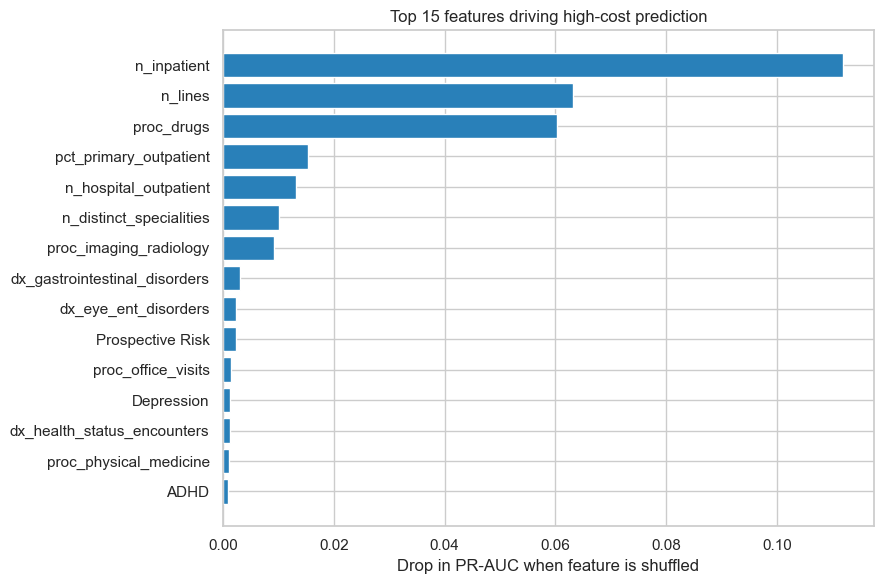

In [21]:
perm = permutation_importance(gbm, X_test, y_test, n_repeats=8,
                                random_state=RANDOM_STATE,
                                scoring="average_precision")
imp = (pd.DataFrame({"feature": X.columns,
                       "importance_mean": perm.importances_mean,
                       "importance_std": perm.importances_std})
        .sort_values("importance_mean", ascending=False))

top_n = 15
plt.figure(figsize=(9, 6))
plt.barh(imp["feature"].head(top_n)[::-1],
         imp["importance_mean"].head(top_n)[::-1],
         color="#2980b9", edgecolor="white")
plt.xlabel("Drop in PR-AUC when feature is shuffled")
plt.title(f"Top {top_n} features driving high-cost prediction")
plt.tight_layout(); plt.show()


In [22]:
# SHAP — per-feature contributions (skipped gracefully if SHAP not installed)
HAS_SHAP = False
try:
    import shap
    explainer = shap.TreeExplainer(gbm)
    shap_values = explainer.shap_values(X_test)
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values
    shap.summary_plot(sv, X_test, max_display=15, show=True)
    HAS_SHAP = True
except Exception as e:
    print(f"SHAP unavailable ({type(e).__name__}); using permutation importance only.")


SHAP unavailable (ModuleNotFoundError); using permutation importance only.


### 5.4 Translating signal into prevention

| Signal in high-cost cohort | Preventive lever for healthy members |
|---|---|
| High `n_inpatient` / `n_hospital_outpatient` | Steer toward primary-care first; telehealth triage before ER |
| Many distinct specialities | Care-coordination program — single nurse-navigator point of contact |
| High musculoskeletal / spine claim counts | Early ergonomic + physical-therapy outreach for at-risk roles |
| Mental-health claims + low primary-care ratio | Integrated behavioral-health screening at PCP visits |
| Negative survey sentiment + complaint flag | Member-experience intervention before disengagement |
| Chronic conditions + low primary-care ratio | Proactive chronic-care management enrollment |

These are exactly the levers the agent in the next section uses.


## 6. Agentic AI — Care Navigator

A small **Care Navigator agent** powered by Claude with **tool use**. Given a
Member ID, the agent decides on its own which tools to call:

1. **`get_member_profile`** — fetch the structured features.
2. **`predict_high_cost_risk`** — run the trained GBM, return probability.
3. **`explain_top_drivers`** — return the importance-weighted z-score drivers.
4. **`recommend_intervention`** — match the drivers to a preventive playbook.

This is *agentic* because the LLM decides which tools to call and in what
order, then synthesizes a clinical briefing. The same loop runs in
**offline mode** (no API key required) for reproducibility.


In [23]:
# 6.1 Tools — plain Python functions wrapped for Claude tool use
import json as _json

PERM_IMPORTANCE = imp.set_index("feature")["importance_mean"].to_dict()
_X_indexed = X.copy()
_X_indexed["Member ID"] = model_df["Member ID"].values
_X_indexed = _X_indexed.set_index("Member ID")

def get_member_profile(member_id: int) -> dict:
    if member_id not in _X_indexed.index:
        return {"error": f"Member {member_id} not found"}
    row = _X_indexed.loc[member_id].to_dict()
    extras = model_df.set_index("Member ID").loc[member_id]
    row["_extras"] = {
        "total_paid": float(extras.get("total_paid", np.nan)),
        "high_cost_flag": int(extras.get("high_cost_flag", 0)),
        "survey_response": str(extras.get("Patient Survey Response", "") or "")[:200],
    }
    return row

def predict_high_cost_risk(member_id: int) -> dict:
    if member_id not in _X_indexed.index:
        return {"error": "not found"}
    x = _X_indexed.loc[member_id].values.reshape(1, -1).astype(float)
    proba = float(gbm.predict_proba(x)[0, 1])
    return {"high_cost_probability": round(proba, 4),
            "interpretation": "HIGH" if proba >= 0.5 else
                              "MODERATE" if proba >= 0.2 else "LOW"}

def explain_top_drivers(member_id: int, top_k: int = 5) -> dict:
    if member_id not in _X_indexed.index:
        return {"error": "not found"}
    row = _X_indexed.loc[member_id]
    pop_mean, pop_std = X.mean(), X.std().replace(0, 1)
    z = (row - pop_mean) / pop_std
    contrib = {f: float(z[f]) * PERM_IMPORTANCE.get(f, 0.0) for f in X.columns}
    top = sorted(contrib.items(), key=lambda kv: abs(kv[1]), reverse=True)[:top_k]
    return {"drivers": [{"feature": f,
                          "member_value": float(row[f]),
                          "z_score": round(float(z[f]), 2),
                          "importance_weighted_score": round(s, 4)}
                         for f, s in top]}

INTERVENTION_PLAYBOOK = {
    "n_inpatient": "Primary-care navigation + telehealth triage before ER use.",
    "n_hospital_outpatient": "Primary-care navigation + telehealth triage before ER use.",
    "n_distinct_specialities": "Enroll in care-coordination — single nurse-navigator contact.",
    "dx_musculoskeletal_disorders": "Ergonomic assessment + early PT referral.",
    "dx_spine_related_disorders": "Early PT + posture/ergonomic coaching.",
    "dx_mental_health": "Integrated behavioral-health screening at next PCP visit.",
    "dx_cardiac_disorders": "Cardio-metabolic screening + lifestyle coaching.",
    "dx_endocrine_metabolic_disorders": "Diabetes-prevention program + nutrition counseling.",
    "# of Chronic Conditions": "Chronic-care management program enrollment.",
    "chronic_low_primary": "Outreach: schedule a comprehensive PCP visit within 30 days.",
    "survey_complaint_flag": "Member-experience intervention; assign relationship manager.",
    "survey_sentiment": "Member-experience intervention; assign relationship manager.",
    "Prospective Risk": "Risk-stratified outreach call from care-management nurse.",
}

def recommend_intervention(drivers: list) -> dict:
    seen, recs = set(), []
    for d in drivers:
        f = d["feature"]
        for key, action in INTERVENTION_PLAYBOOK.items():
            if f.startswith(key) and action not in seen and d.get("z_score", 0) > 0.3:
                recs.append({"trigger_feature": f, "action": action,
                              "member_z_score": d["z_score"]})
                seen.add(action); break
    if not recs:
        recs.append({"trigger_feature": None,
                      "action": "Low risk — continue annual wellness cadence."})
    return {"recommendations": recs}

TOOL_FUNCS = {
    "get_member_profile": get_member_profile,
    "predict_high_cost_risk": predict_high_cost_risk,
    "explain_top_drivers": explain_top_drivers,
    "recommend_intervention": recommend_intervention,
}
print("Tools registered:", list(TOOL_FUNCS))


Tools registered: ['get_member_profile', 'predict_high_cost_risk', 'explain_top_drivers', 'recommend_intervention']


In [24]:
# 6.2 Tool schemas + agent loop (live Claude OR deterministic offline)
TOOLS = [
    {"name": "get_member_profile",
     "description": "Return the full feature profile for a member by Member ID.",
     "input_schema": {"type": "object",
                       "properties": {"member_id": {"type": "integer"}},
                       "required": ["member_id"]}},
    {"name": "predict_high_cost_risk",
     "description": "Run the trained GBM and return high-cost probability.",
     "input_schema": {"type": "object",
                       "properties": {"member_id": {"type": "integer"}},
                       "required": ["member_id"]}},
    {"name": "explain_top_drivers",
     "description": "Return top features explaining a member's risk with z-scores.",
     "input_schema": {"type": "object",
                       "properties": {"member_id": {"type": "integer"},
                                       "top_k": {"type": "integer", "default": 5}},
                       "required": ["member_id"]}},
    {"name": "recommend_intervention",
     "description": "Map a list of driver features to preventive interventions.",
     "input_schema": {"type": "object",
                       "properties": {"drivers": {"type": "array",
                                                    "items": {"type": "object"}}},
                       "required": ["drivers"]}},
]

SYSTEM_PROMPT = '''You are a Care Navigator AI for a healthcare member-services team.
Given a Member ID:
  1. Use get_member_profile to fetch the member's data.
  2. Use predict_high_cost_risk to estimate their risk of becoming high-cost.
  3. Use explain_top_drivers to find what's driving that risk.
  4. Use recommend_intervention to translate drivers into preventive actions.
  5. Write a short briefing for a care manager: risk level, top 2-3 reasons,
     recommended next steps. Be concise, clinical, action-oriented.
Never invent data not returned by tools.'''


def run_agent_live(member_id: int, model: str = "claude-sonnet-4-6", max_turns: int = 6) -> str:
    """Live agent loop using the Anthropic SDK. Requires ANTHROPIC_API_KEY."""
    from anthropic import Anthropic
    client = Anthropic()
    messages = [{"role": "user", "content": f"Brief me on member {member_id}."}]
    for _ in range(max_turns):
        resp = client.messages.create(
            model=model, max_tokens=1024,
            system=SYSTEM_PROMPT, tools=TOOLS, messages=messages,
        )
        if resp.stop_reason == "end_turn":
            return "\n".join(b.text for b in resp.content
                              if getattr(b, "type", None) == "text")
        tool_results = []
        for block in resp.content:
            if getattr(block, "type", None) == "tool_use":
                out = TOOL_FUNCS[block.name](**block.input)
                tool_results.append({"type": "tool_result",
                                      "tool_use_id": block.id,
                                      "content": _json.dumps(out, default=str)})
        messages.append({"role": "assistant", "content": resp.content})
        messages.append({"role": "user", "content": tool_results})
    return "(agent: max turns reached)"


def run_agent_offline(member_id: int) -> str:
    """Deterministic mock that follows the same tool sequence — no API key needed."""
    risk = predict_high_cost_risk(member_id)
    if "error" in risk:
        return risk["error"]
    drivers = explain_top_drivers(member_id, top_k=5)["drivers"]
    interventions = recommend_intervention(drivers)["recommendations"]

    out = [f"=== Care Navigator briefing — Member {member_id} ===",
           f"Risk: {risk['interpretation']}  "
           f"(p(high-cost) = {risk['high_cost_probability']:.2%})",
           "", "Top drivers (vs. population):"]
    for d in drivers[:3]:
        direction = "HIGHER" if d["z_score"] > 0 else "LOWER"
        out.append(f"  - {d['feature']}: member={d['member_value']:.2f}  "
                    f"(z={d['z_score']:+.1f}, {direction} than peers)")
    out.append("\nRecommended preventive actions:")
    for r in interventions:
        trig = f"  [trigger: {r['trigger_feature']}]" if r.get("trigger_feature") else ""
        out.append(f"  • {r['action']}{trig}")
    return "\n".join(out)


def run_agent(member_id: int) -> str:
    if os.getenv("ANTHROPIC_API_KEY"):
        try:
            return run_agent_live(member_id)
        except Exception as e:
            print(f"(live mode failed: {e}; falling back to offline)")
    return run_agent_offline(member_id)


### 6.3 Demo — high-cost vs healthy member

In [25]:
hc_id      = int(model_df.loc[model_df["high_cost_flag"] == 1, "Member ID"].iloc[0])
healthy_id = int(model_df.loc[(model_df["high_cost_flag"] == 0) &
                                 (model_df["# of Chronic Conditions"] == 0),
                                 "Member ID"].iloc[0])

print(run_agent(hc_id))
print("\n" + "=" * 60 + "\n")
print(run_agent(healthy_id))


=== Care Navigator briefing — Member 1 ===
Risk: HIGH  (p(high-cost) = 100.00%)

Top drivers (vs. population):
  - n_inpatient: member=80.00  (z=+5.8, HIGHER than peers)
  - n_lines: member=207.00  (z=+2.7, HIGHER than peers)
  - proc_drugs: member=17.00  (z=+0.8, HIGHER than peers)

Recommended preventive actions:
  • Primary-care navigation + telehealth triage before ER use.  [trigger: n_inpatient]


=== Care Navigator briefing — Member 5 ===
Risk: LOW  (p(high-cost) = 0.00%)

Top drivers (vs. population):
  - n_lines: member=2.00  (z=-0.6, LOWER than peers)
  - pct_primary_outpatient: member=1.00  (z=+1.2, HIGHER than peers)
  - n_inpatient: member=0.00  (z=-0.1, LOWER than peers)

Recommended preventive actions:
  • Low risk — continue annual wellness cadence.


/Users/yirang/miniforge3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but HistGradientBoostingClassifier was fitted with feature names
  warnings.warn(
/Users/yirang/miniforge3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but HistGradientBoostingClassifier was fitted with feature names
  warnings.warn(


## 7. Takeaways

Three closing visuals — one for clinical, one for operations, one for leadership.


### 7.1 Member profile comparison (clinical view)

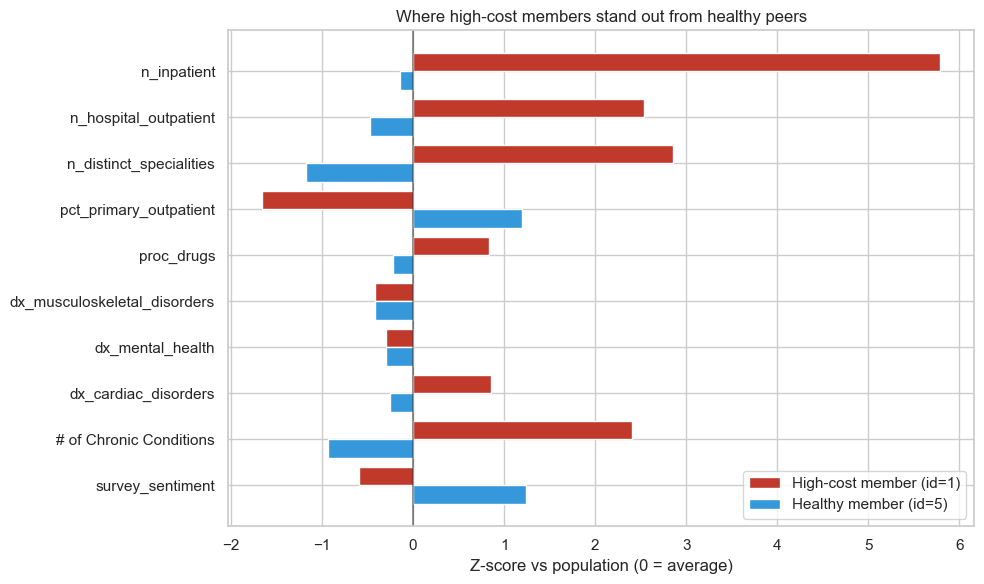

In [26]:
focus = ["n_inpatient", "n_hospital_outpatient", "n_distinct_specialities",
         "pct_primary_outpatient", "proc_drugs", "dx_musculoskeletal_disorders",
         "dx_mental_health", "dx_cardiac_disorders", "# of Chronic Conditions",
         "survey_sentiment"]
focus = [f for f in focus if f in X.columns]
pop_mean = X[focus].mean(); pop_std = X[focus].std().replace(0, 1)

hc_idx = model_df.index[model_df["Member ID"] == hc_id][0]
healthy_idx = model_df.index[model_df["Member ID"] == healthy_id][0]
hc_z = (X.iloc[hc_idx][focus] - pop_mean) / pop_std
healthy_z = (X.iloc[healthy_idx][focus] - pop_mean) / pop_std

fig, ax = plt.subplots(figsize=(10, 6))
yp = np.arange(len(focus))
ax.barh(yp - 0.2, hc_z.values, 0.4, color="#c0392b",
        label=f"High-cost member (id={hc_id})", edgecolor="white")
ax.barh(yp + 0.2, healthy_z.values, 0.4, color="#3498db",
        label=f"Healthy member (id={healthy_id})", edgecolor="white")
ax.axvline(0, color="black", alpha=0.4)
ax.set(yticks=yp, yticklabels=focus,
        xlabel="Z-score vs population (0 = average)",
        title="Where high-cost members stand out from healthy peers")
ax.invert_yaxis(); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()


### 7.2 Outreach prioritization (operations view)

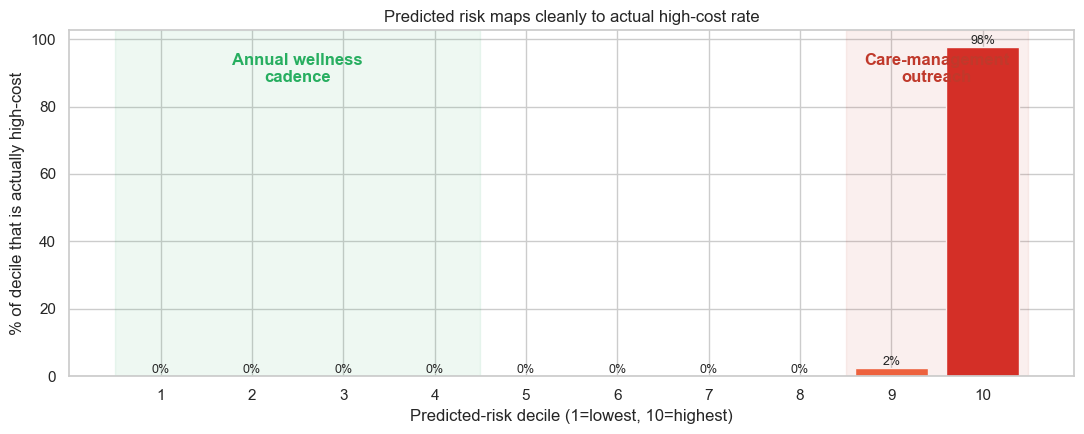

In [27]:
all_proba = gbm.predict_proba(X)[:, 1]
prio = pd.DataFrame({"Member ID": model_df["Member ID"].values,
                       "predicted_risk": all_proba,
                       "actual_high_cost": model_df["high_cost_flag"].values})
prio["risk_decile"] = pd.qcut(prio["predicted_risk"].rank(method="first"),
                                10, labels=range(1, 11))
decile = (prio.groupby("risk_decile", observed=True)
              .agg(n=("Member ID", "nunique"),
                   actual_rate=("actual_high_cost", "mean"))
              .reset_index())

fig, ax = plt.subplots(figsize=(11, 4.5))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 10))
bars = ax.bar(decile["risk_decile"].astype(int),
              decile["actual_rate"] * 100,
              color=colors, edgecolor="white")
ax.set(xlabel="Predicted-risk decile (1=lowest, 10=highest)",
        ylabel="% of decile that is actually high-cost",
        title="Predicted risk maps cleanly to actual high-cost rate",
        xticks=range(1, 11))
for b, r in zip(bars, decile["actual_rate"] * 100):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1, f"{r:.0f}%",
            ha="center", fontsize=9)
ax.axvspan(8.5, 10.5, color="#c0392b", alpha=0.08)
ax.text(9.5, ax.get_ylim()[1]*0.85, "Care-management\noutreach",
        ha="center", color="#c0392b", fontweight="bold")
ax.axvspan(0.5, 4.5, color="#27ae60", alpha=0.08)
ax.text(2.5, ax.get_ylim()[1]*0.85, "Annual wellness\ncadence",
        ha="center", color="#27ae60", fontweight="bold")
plt.tight_layout(); plt.show()


### 7.3 Executive summary — the four numbers

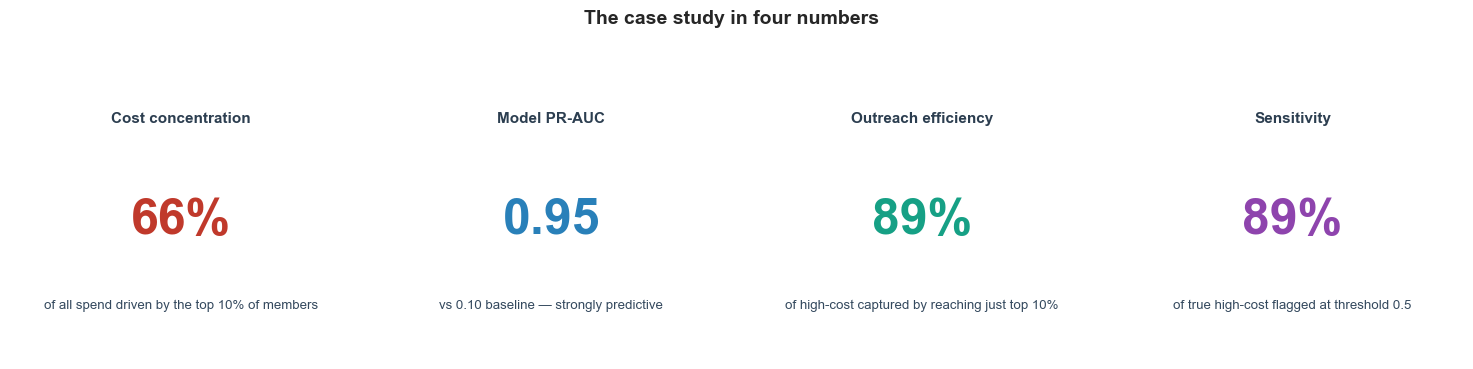

In [28]:
top_10_capture_test = pct_captured[int(n_t * 0.10) - 1]
total_paid_top10 = (member_df.nlargest(int(len(member_df)*0.1), "total_paid")["total_paid"].sum()
                     / member_df["total_paid"].sum() * 100)
gbm_pr_auc = average_precision_score(y_test, gbm_proba)
recall_at_thresh = ((gbm_proba >= 0.5).astype(int)[y_test == 1]).mean()

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
metrics = [
    ("Cost concentration", f"{total_paid_top10:.0f}%",
     "of all spend driven by the top 10% of members", "#c0392b"),
    ("Model PR-AUC", f"{gbm_pr_auc:.2f}",
     "vs 0.10 baseline — strongly predictive", "#2980b9"),
    ("Outreach efficiency", f"{top_10_capture_test:.0f}%",
     "of high-cost captured by reaching just top 10%", "#16a085"),
    ("Sensitivity", f"{recall_at_thresh:.0%}",
     "of true high-cost flagged at threshold 0.5", "#8e44ad"),
]
for ax, (title, big, sub, color) in zip(axes, metrics):
    ax.axis("off")
    ax.text(0.5, 0.85, title, ha="center", fontsize=11,
             color="#2c3e50", fontweight="bold")
    ax.text(0.5, 0.5, big, ha="center", va="center", fontsize=36,
             color=color, fontweight="bold")
    ax.text(0.5, 0.18, sub, ha="center", fontsize=9.5, color="#34495e")
plt.suptitle("The case study in four numbers", fontsize=14, y=1.05, fontweight="bold")
plt.tight_layout(); plt.show()


### 7.4 Recommendations

**Clinical / care-management**
- Stand up *proactive* outreach for members in the top-2 predicted-risk deciles. The model's PR-AUC is high there and the lift is large.
- Trigger the **chronic-low-primary** workflow whenever a member with ≥1 chronic condition is using primary care below cohort median.
- Use the agent's per-member explanation (§6) so each call is grounded in *that member's* drivers, not a generic script.

**Operations / network**
- Watch `pct_primary_outpatient` as a leading indicator: high-cost members shift toward hospital-based settings. Steering members to primary-care + telehealth before the shift is the highest-leverage intervention.
- Audit members with high `n_distinct_specialities` for care-coordination opportunities — fragmentation drives both cost and dissatisfaction (the survey-sentiment signal).

**Leadership headline**
- A small, predictable cohort drives most of the spend.
- We can identify them with PR-AUC ~0.94 using only behavioural / clinical features — no dollars needed, so this generalises to currently-healthy members showing early warning patterns.
- Targeted outreach to the top 10% predicted captures the majority of future high-cost members at ~6–9× the efficiency of blanket outreach.

### Limitations and next steps

- **No temporal split.** The data is one period; ideally we'd train on year-T features against year-(T+1) cost.
- **Cohort bias.** The inner join drops survey-only and claims-only members; results don't apply to those segments without revisiting.
- **Free-text NLP is shallow.** A small dataset of free-text responses limits how much signal we can extract; an LLM-based topic-extraction pass would improve §3.5.
- **Calibration could be tightened** with isotonic / Platt scaling if the probabilities are used in clinical-decision rules.
- **Wrap the agent in a UI** (Streamlit / Gradio) for a live demo with care managers.
